In [10]:
# auto reload modules
%load_ext autoreload
%autoreload 2

In [11]:
import matplotlib.pyplot as plt
from cns.process.binning import group_bins, sum_cns
from cns.utils.selection import get_cns_for_type
from cns.display.plot import fig_lines, plot_lines
from cns.data_utils import load_merged_samples, load_merged_bins, select_CNS_samples

In [12]:
samples_df = load_merged_samples()
cns_df = load_merged_bins(samples_df, "3MB")

<Axes: xlabel='type'>

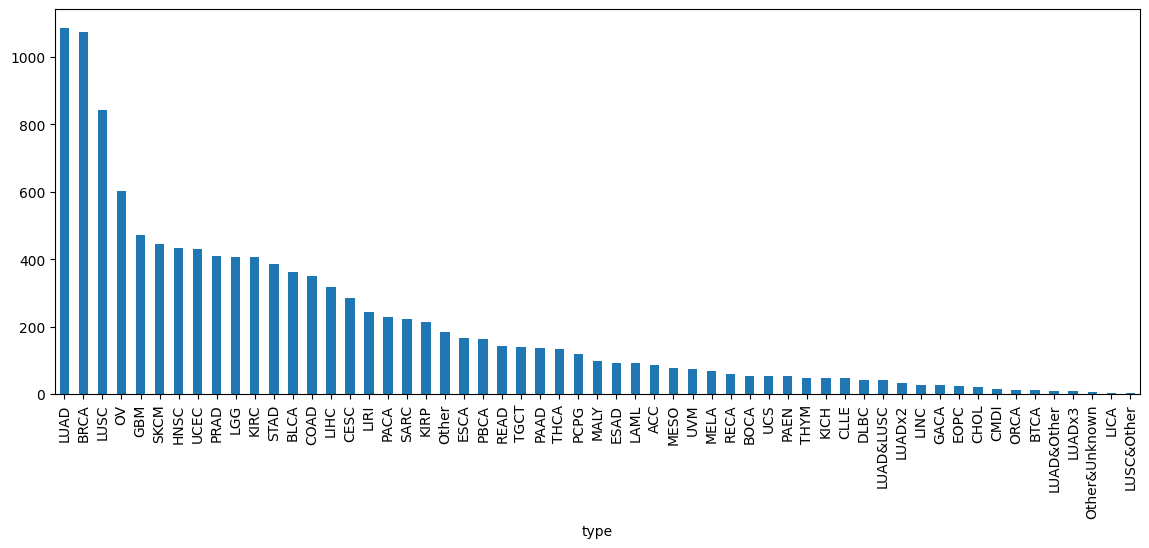

In [13]:
plt.rcParams["figure.figsize"] = (14,5)
samples_df["type"].value_counts().plot(kind="bar")

In [8]:
samples_df["type"].str.contains('x|&').sum()

107

Text(0.5, 1.0, 'Joint 11558 samples')

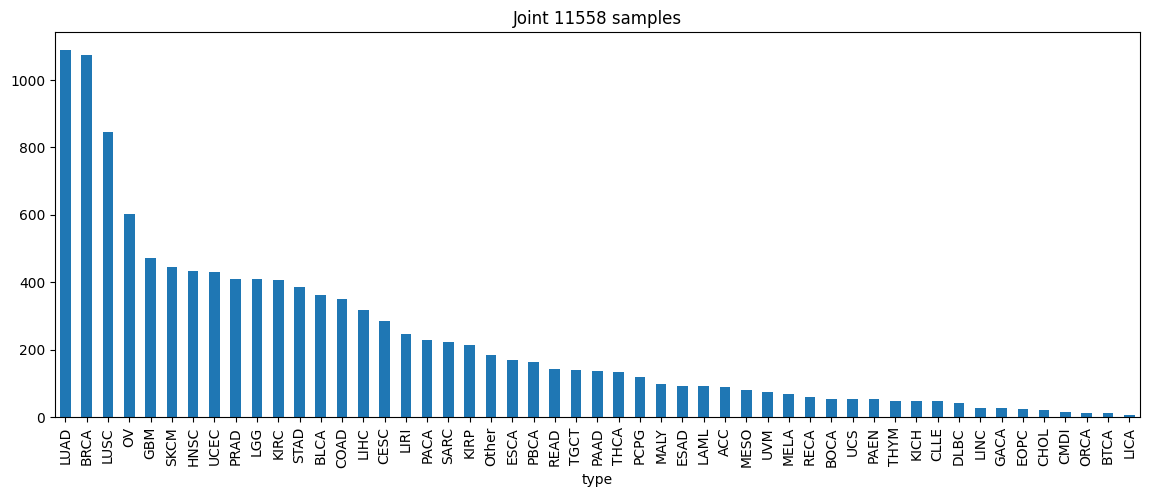

In [9]:
filtered_df = samples_df[~samples_df["type"].fillna('').str.contains('x|&')]
filtered_df["type"].value_counts().plot(kind="bar")
plt.title(f"Joint {len(filtered_df)} samples")

(<Figure size 3600x600 with 1 Axes>,
 <Axes: xlabel='position on linear genome', ylabel='mean CN per bin'>)

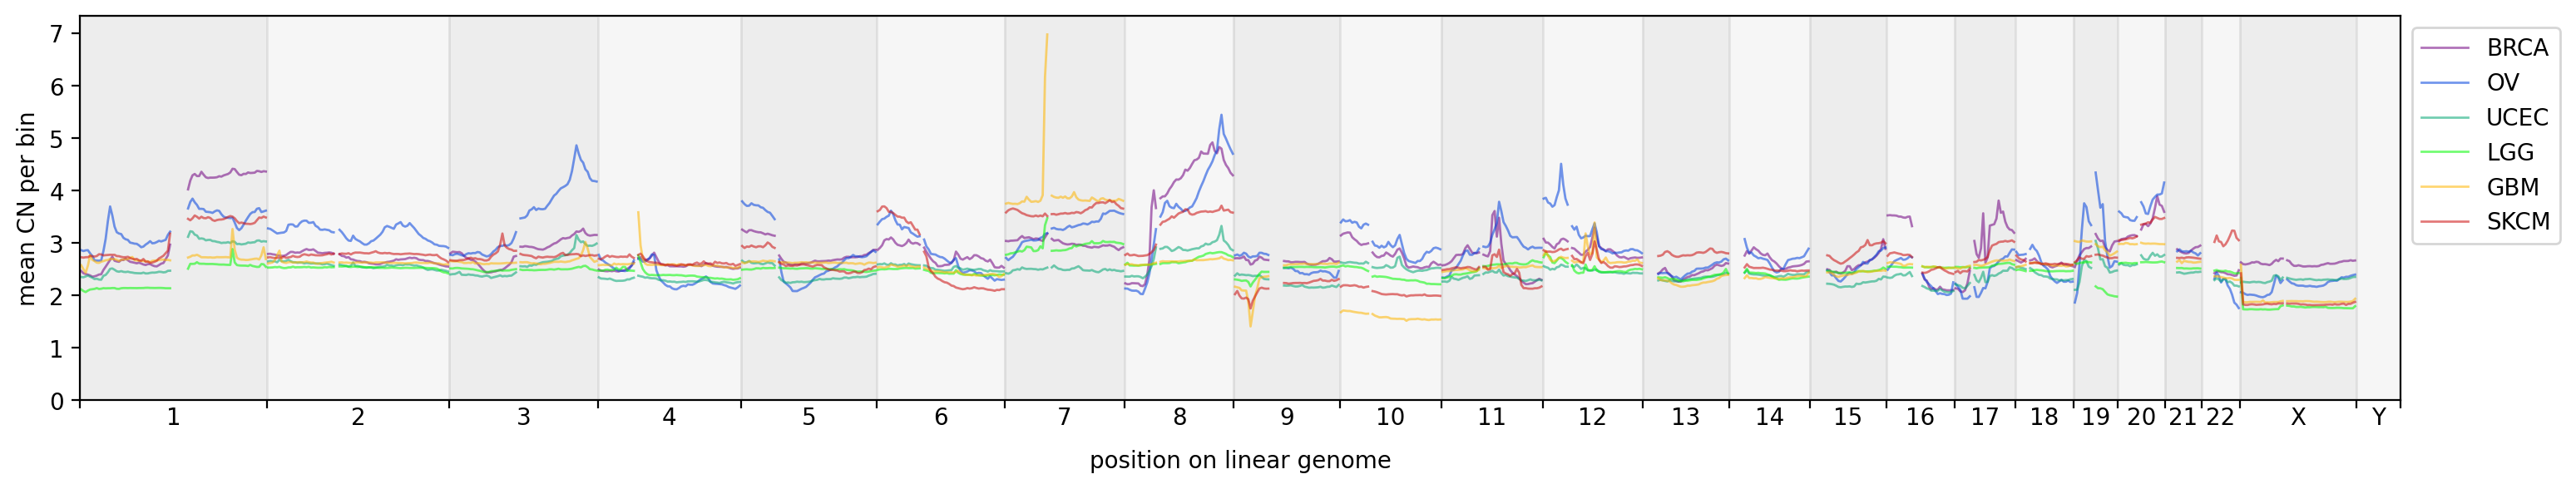

In [22]:
tcga_set = samples_df.query("source == 'TCGA'")
tcga_cns = select_CNS_samples(cns_df, tcga_set)
top_6 = tcga_set.value_counts("type")[:6].index.values
selection_tcga = [group_bins(get_cns_for_type(cns_df, samples_df, type)) for type in top_6]
fig_lines(selection_tcga, top_6, column="total_cn", dpi=200)

(<Figure size 1800x300 with 1 Axes>,
 <Axes: xlabel='position on linear genome', ylabel='mean CN per bin'>)

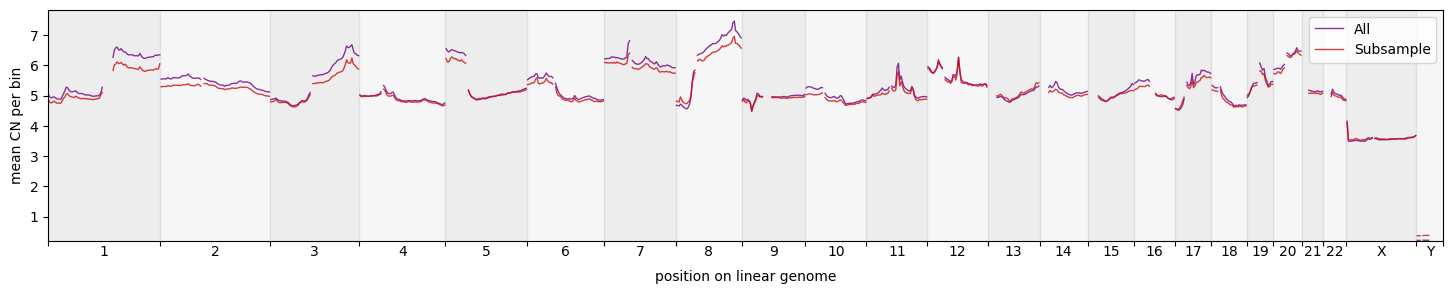

In [25]:
above_50 = samples_df["type"].value_counts().where(lambda x: x >= 50).where(lambda x: x != "Other").dropna().index.values
all_samples = samples_df.query("type in @above_50")
sub_samples = all_samples.groupby('type').apply(lambda x: x.sample(n=50, replace=True) if len(x) > 50 else x, include_groups=False).reset_index().set_index('sample_id')
# select only 50 samples for each type to obtain balanced mean
selection = [sum_cns(group_bins(select_CNS_samples(cns_df, samples))) for samples in [all_samples, sub_samples]]
fig_lines(selection, ["All", "Subsample"], column="total_cn", dpi=100)
